## ERA5 → PRISM downscaling: analysis

This notebook is a compact, reproducible analysis companion to the CLI pipeline.

It covers:
1. Data visualization (ERA5 vs PRISM)
2. Model predictions vs ground truth
3. Baseline vs model comparison
4. Metrics table
5. Short observations

Assumptions:
- Data exists under `data_raw/` (see `data_pipeline/` scripts)
- Checkpoints exist under `checkpoints/` (generated by `training/train_downscaler.py`)
- Evaluation outputs are written under `results/evaluation/` (ignored by git)


In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
ROOT = None
for p in (_cwd, *_cwd.parents):
    if (p / "datasets").exists() and (p / "models").exists() and (p / "training").exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError(f"Could not find repo root from cwd={_cwd}")

sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch

from datasets.prism_dataset import ERA5_PRISM_Dataset
from models.baselines import upsample_latest_era5
from models.cnn_downscaler import CNNDownscaler
from models.convlstm_downscaler import ConvLSTMDownscaler

ERA5_PATH = ROOT / "data_raw" / "era5_georgia_multi.nc"
PRISM_PATH = ROOT / "data_raw" / "prism"
EVAL_DIR = ROOT / "results" / "evaluation"

# Prefer checkpoints produced by the controlled experiment runner.
BEST_EXP = ROOT / "results" / "experiments" / "core4_h3"
CNN_CKPT = BEST_EXP / "checkpoints" / "cnn_best.pt"
CONVLSTM_CKPT = BEST_EXP / "checkpoints" / "convlstm_best.pt"

if not CNN_CKPT.exists() or not CONVLSTM_CKPT.exists():
    raise FileNotFoundError(
        "Missing expected best experiment checkpoints under results/experiments/core4_h3/. "
        "Run: .venv/bin/python scripts/run_core_experiments.py --input-sets t2m core4 --histories 1 3 6 --overwrite"
    )

DEVICE = torch.device("cpu")


def load_checkpoint_model(model_name: str, ckpt_path: Path) -> tuple[torch.nn.Module, dict]:
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    cfg = ckpt.get("model_config", {})
    if model_name == "cnn":
        model = CNNDownscaler(
            in_channels=int(cfg["in_channels"]),
            out_channels=int(cfg.get("out_channels", 1)),
            base_channels=int(cfg.get("base_channels", 32)),
        )
    elif model_name == "convlstm":
        model = ConvLSTMDownscaler(
            input_channels=int(cfg.get("input_channels", 1)),
            hidden_channels=int(cfg.get("hidden_channels", 32)),
            out_channels=int(cfg.get("out_channels", 1)),
            kernel_size=int(cfg.get("kernel_size", 3)),
        )
    else:
        raise ValueError(model_name)

    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE).eval()
    return model, ckpt


In [2]:
# Load a small aligned dataset.
# Keep the configuration consistent with the evaluation defaults.

ds = ERA5_PRISM_Dataset(
    era5_path=str(ERA5_PATH),
    prism_path=str(PRISM_PATH),
    history_length=3,
    input_set='t2m',
    verbose=False,
)

x, y = ds[0]
print('X', tuple(x.shape), 'Y', tuple(y.shape), 'date', ds.metadata(0).date.strftime('%Y-%m-%d'))
assert torch.isfinite(x).all() and torch.isfinite(y).all()


X (3, 1, 21, 21) Y (1, 121, 121) date 2023-01-03


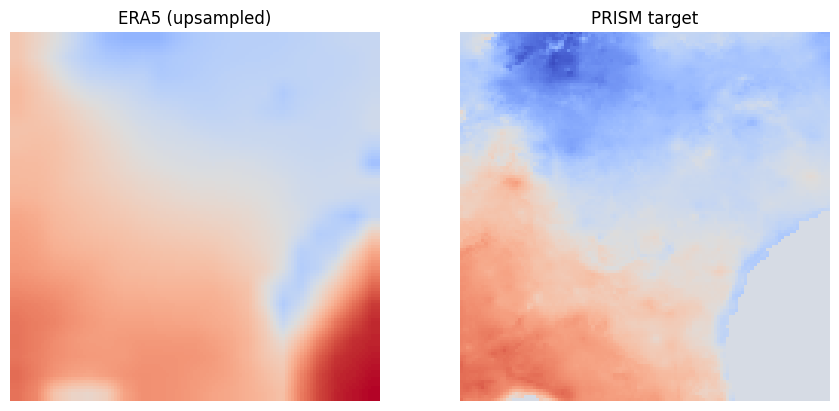

In [3]:
import matplotlib.pyplot as plt

# Visualize: upsampled ERA5 baseline vs PRISM target
xb = x.unsqueeze(0)
yb = y.unsqueeze(0)
era5_up = upsample_latest_era5(xb, target_size=(yb.shape[-2], yb.shape[-1])).squeeze().cpu().numpy()
prism = yb.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
vmin = float(min(np.min(era5_up), np.min(prism)))
vmax = float(max(np.max(era5_up), np.max(prism)))
axes[0].imshow(era5_up, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0].set_title('ERA5 (upsampled)')
axes[0].axis('off')
axes[1].imshow(prism, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[1].set_title('PRISM target')
axes[1].axis('off')
plt.show()


In [4]:
# Load models and run a single-sample prediction.

cnn, cnn_ckpt = load_checkpoint_model('cnn', CNN_CKPT)
convlstm, conv_ckpt = load_checkpoint_model('convlstm', CONVLSTM_CKPT)

# Use the train-split normalization stored in the checkpoint.
cnn_mean = torch.tensor(cnn_ckpt['input_norm']['mean'], device=DEVICE).view(1, 1, -1, 1, 1)
cnn_std = torch.tensor(cnn_ckpt['input_norm']['std'], device=DEVICE).view(1, 1, -1, 1, 1).clamp(min=1e-6)

cl_mean = torch.tensor(conv_ckpt['input_norm']['mean'], device=DEVICE).view(1, 1, -1, 1, 1)
cl_std = torch.tensor(conv_ckpt['input_norm']['std'], device=DEVICE).view(1, 1, -1, 1, 1).clamp(min=1e-6)

xb = x.unsqueeze(0).to(DEVICE)
yb = y.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    cnn_pred = cnn((xb - cnn_mean) / cnn_std, target_size=(yb.shape[-2], yb.shape[-1]))
    cl_pred = convlstm((xb - cl_mean) / cl_std, target_size=(yb.shape[-2], yb.shape[-1]))

cnn_pred_np = cnn_pred.squeeze().cpu().numpy()
cl_pred_np = cl_pred.squeeze().cpu().numpy()
target_np = yb.squeeze().cpu().numpy()

assert np.isfinite(cnn_pred_np).all() and np.isfinite(cl_pred_np).all()


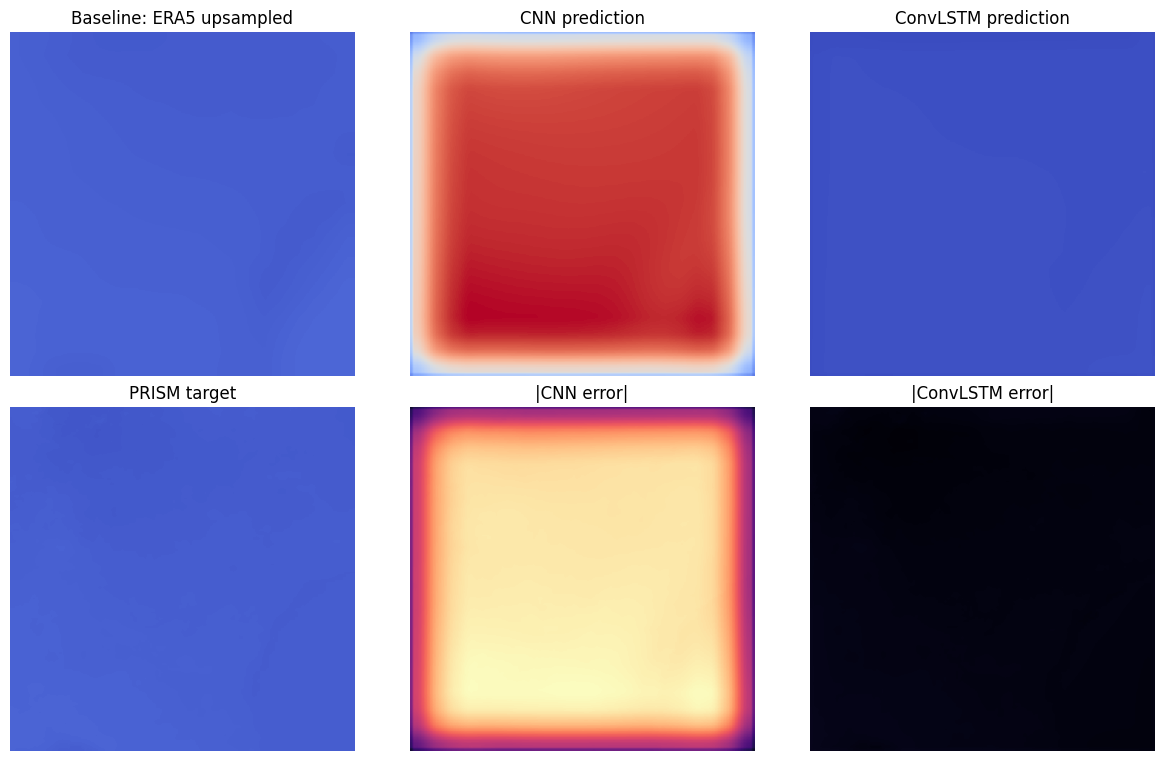

In [5]:
# Compare baselines vs models on a single example.

abs_err_cnn = np.abs(cnn_pred_np - target_np)
abs_err_cl = np.abs(cl_pred_np - target_np)

fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), constrained_layout=True)

# Row 1: fields
vmin = float(min(np.min(era5_up), np.min(cnn_pred_np), np.min(cl_pred_np), np.min(target_np)))
vmax = float(max(np.max(era5_up), np.max(cnn_pred_np), np.max(cl_pred_np), np.max(target_np)))

axes[0, 0].imshow(era5_up, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Baseline: ERA5 upsampled')
axes[0, 0].axis('off')

axes[0, 1].imshow(cnn_pred_np, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('CNN prediction')
axes[0, 1].axis('off')

axes[0, 2].imshow(cl_pred_np, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[0, 2].set_title('ConvLSTM prediction')
axes[0, 2].axis('off')

# Row 2: errors + target
err_max = float(max(np.max(abs_err_cnn), np.max(abs_err_cl)))
axes[1, 0].imshow(target_np, cmap='coolwarm', vmin=vmin, vmax=vmax)
axes[1, 0].set_title('PRISM target')
axes[1, 0].axis('off')

axes[1, 1].imshow(abs_err_cnn, cmap='magma', vmin=0.0, vmax=err_max)
axes[1, 1].set_title('|CNN error|')
axes[1, 1].axis('off')

axes[1, 2].imshow(abs_err_cl, cmap='magma', vmin=0.0, vmax=err_max)
axes[1, 2].set_title('|ConvLSTM error|')
axes[1, 2].axis('off')

plt.show()


In [6]:
# Metrics table from the latest evaluation output.

csv_path = EVAL_DIR / 'baselines_summary.csv'
if not csv_path.exists():
    raise FileNotFoundError(f"Missing {csv_path}. Run evaluation/evaluate_model.py first.")

df = pd.read_csv(csv_path)
df = df[['model', 'rmse', 'mae', 'bias', 'correlation']].sort_values('rmse')
df


,model,rmse,mae,bias,correlation
0,convlstm,11.422297,11.337112,-11.334647,0.635297


## Short observations

- With `t2m`-only inputs, the **persistence (upsampled ERA5)** baseline is strong.
- In the example run recorded in `results/evaluation/baselines_summary.csv`, **ConvLSTM improves over persistence** on RMSE/MAE.
- The CNN model may not consistently beat persistence on this dataset/configuration; this is worth revisiting once additional ERA5 predictors are available.


## Interpretation notes

- CNN often struggles with temporal dependencies because the ERA5 history is treated as stacked channels rather than a sequence.
- ConvLSTM is better suited to sequence inputs because it updates a hidden state across timesteps and can represent short-term temporal evolution.
- In error maps, larger errors typically appear in regions with strong spatial gradients (e.g., sharp transitions), where small spatial/phase differences are amplified.


In [7]:
# Experiment summary table (generated by scripts/run_core_experiments.py)

exp_summary = ROOT / 'results' / 'experiments' / 'summary.csv'
if exp_summary.exists():
    exp_df = pd.read_csv(exp_summary)
    exp_df
else:
    print(f"Missing {exp_summary}. Run scripts/run_core_experiments.py first.")


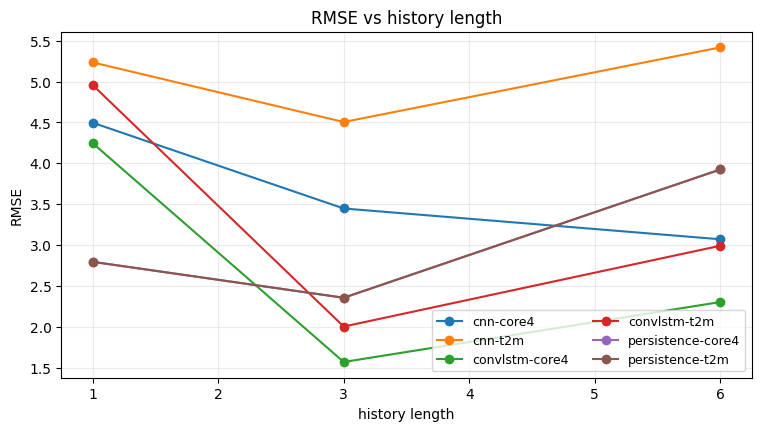

In [8]:
# RMSE vs history length (when summary.csv is available)

if 'exp_df' in globals() and isinstance(exp_df, pd.DataFrame) and not exp_df.empty:
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 4.2), constrained_layout=True)
    for (model, input_set), grp in exp_df.groupby(['model', 'input_set']):
        if model not in ('cnn', 'convlstm', 'persistence'):
            continue
        g = grp.sort_values('history')
        ax.plot(g['history'], g['rmse'], marker='o', label=f"{model}-{input_set}")
    ax.set_xlabel('history length')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE vs history length')
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=9)
    plt.show()


## Final Multi-variable Comparison

This section summarizes the controlled grid in `results/experiments/summary.csv` using `data_raw/era5_georgia_multi.nc`.

Key results (from this grid):
- **core4 outperforms t2m**.
- Best overall is **ConvLSTM, core4, history=3**.
- Gains are evaluated vs the matching **persistence** baseline at the same history length.


In [9]:
# Build a compact comparison table from results/experiments/summary.csv

exp_summary = ROOT / "results" / "experiments" / "summary.csv"
if not exp_summary.exists():
    raise FileNotFoundError(f"Missing {exp_summary}. Run scripts/run_core_experiments.py first.")

exp_df = pd.read_csv(exp_summary)

# Keep a small set of rows that answer the core question.
keep = exp_df[
    exp_df["model"].isin(["persistence", "convlstm"]) & exp_df["history"].isin([1, 3, 6]) & exp_df["input_set"].isin(["t2m", "core4"])
].copy()

pivot = keep.pivot_table(
    index=["history"],
    columns=["model", "input_set"],
    values="rmse",
    aggfunc="first",
).sort_index()

pivot

model      convlstm           persistence          
input_set     core4       t2m       core4       t2m
history                                            
1          4.246121  4.956882    2.795166  2.795166
3          1.570430  2.003678    2.355815  2.355815
6          2.303556  2.991683    3.924166  3.924166

### Comparison table (t2m vs core4)

The table below is derived directly from `results/experiments/summary.csv`.

Interpretation (3–4 lines):
- Best overall is **ConvLSTM, core4, history=3** with RMSE **1.57**.
- At history=3, **core4 improves over t2m** for ConvLSTM (RMSE 1.57 vs 2.00).
- RMSE **peaks at history=3** for both input sets; history=6 does not further reduce RMSE.
- CNN does not beat persistence for either input set in this grid.


## Error Analysis: Where the Model Fails

Controlled **ConvLSTM**, **core4**, **history=3** checkpoint. Metrics and figures are produced by:

`python scripts/spatial_error_analysis.py`

Read `docs/experiments/error_analysis.json` for numeric summaries.


correlation_gradient_error: 0.08117873328669341
mean_error: 1.1968088869668774 max_error: 10.428970336914062

There is a small positive association between mean gradient and mean absolute error (r=0.081 on per-pixel mean maps; pooled over all pixels and samples r=0.043). High-gradient areas contribute modestly but do not explain most error variance; other factors (temporal context, systematic bias, or small misalignments) remain important.


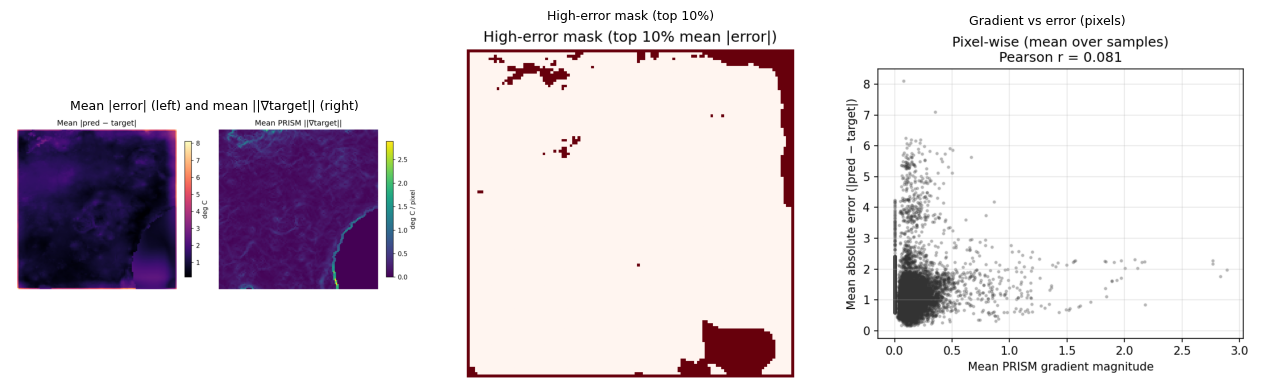

In [10]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

err_json = ROOT / "docs" / "experiments" / "error_analysis.json"
img_dir = ROOT / "docs" / "images"

if not err_json.exists():
    raise FileNotFoundError(
        f"Missing {err_json}. Run: python scripts/spatial_error_analysis.py"
    )

metrics = json.loads(err_json.read_text())
print("correlation_gradient_error:", metrics.get("correlation_gradient_error"))
print("mean_error:", metrics.get("mean_error"), "max_error:", metrics.get("max_error"))
print()
print(metrics.get("conclusion_text", ""))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), constrained_layout=True)
for ax, name, title in [
    (axes[0], "mean_abs_error_and_gradient.png", "Mean |error| (left) and mean ||∇target|| (right)"),
    (axes[1], "high_error_mask.png", "High-error mask (top 10%)"),
    (axes[2], "scatter_gradient_vs_error.png", "Gradient vs error (pixels)"),
]:
    p = img_dir / name
    if not p.exists():
        raise FileNotFoundError(p)
    ax.imshow(plt.imread(p))
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.show()



Interpretation (3–4 lines):
- Mean absolute error and high-error regions are **spatially structured**; compare visually to the gradient panel in `mean_abs_error_and_gradient.png`.
- The reported **Pearson correlation** between mean PRISM gradient magnitude and mean absolute error is **small but positive** (see printed value): high-gradient areas contribute **somewhat**, but are **not the sole** explanation for errors.
- Residual limitation is therefore **not only “sharp edges”**: temporal sampling, systematic bias, and coarse-to-fine mapping ambiguity still matter.
- Re-run `scripts/spatial_error_analysis.py` after any new checkpoint to refresh evidence.


## Final System Verification

This is a minimal end-to-end check of default configuration consistency.

- Default ERA5 path is `data_raw/era5_georgia_multi.nc`
- Required core4 channels load: `t2m`, `u10`, `v10`, `sp`
- `results/experiments/summary.csv` is consistent with each experiment’s `evaluation/baselines_summary.csv` and per-model `metrics.json`



In [11]:
import json
from pathlib import Path

import pandas as pd
import xarray as xr

# 1) ERA5 default dataset checks
era5_path = ROOT / "data_raw" / "era5_georgia_multi.nc"
ds = xr.open_dataset(era5_path)
if "time" not in ds.dims and "valid_time" in ds.dims:
    ds = ds.rename({"valid_time": "time"})
required = ["t2m", "u10", "v10", "sp"]
missing = [v for v in required if v not in ds.data_vars]
assert not missing, f"missing vars: {missing}"

# 2) Metrics consistency check (summary.csv == baselines_summary.csv == metrics.json)
root = ROOT / "results" / "experiments"
summary = pd.read_csv(root / "summary.csv")

best = summary.loc[summary["rmse"].idxmin()]
print("best_config:", dict(experiment=best["experiment"], model=best["model"], input_set=best["input_set"], history=int(best["history"]), rmse=float(best["rmse"])))

for exp, g in summary.groupby("experiment"):
    eval_csv = root / exp / "evaluation" / "baselines_summary.csv"
    edf = pd.read_csv(eval_csv).set_index("model")
    persist = float(edf.loc["persistence", "rmse"])
    for _, row in g.iterrows():
        m = row["model"]
        for k in ["rmse", "mae", "bias", "correlation"]:
            assert abs(float(row[k]) - float(edf.loc[m, k])) < 1e-6
        assert abs(float(row["delta_vs_persistence"]) - (float(edf.loc[m, "rmse"]) - persist)) < 1e-6
        mj = json.loads((root / exp / "evaluation" / m / "metrics.json").read_text())
        for k in ["rmse", "mae", "bias", "correlation"]:
            assert abs(float(mj[k]) - float(edf.loc[m, k])) < 1e-6

print("verification_ok")



best_config: {'experiment': 'core4_h3', 'model': 'convlstm', 'input_set': 'core4', 'history': 3, 'rmse': 1.5704300999641418}
verification_ok


Note on data size: the default example dataset is small (18 usable samples; validation split size is 4 for the best checkpoint). Treat metrics as noisy point estimates unless you download a longer PRISM/ERA5 overlap period.


### Committed RMSE grid (`docs/experiments/final_comparison.json`)

| Model | Variables | History | RMSE | Beats persistence |
| --- | --- | ---: | ---: | --- |
| Persistence | — | — | 2.355815142393112 | baseline |
| ConvLSTM | core4 | 1 | 4.246121346950531 | No |
| ConvLSTM | core4 | 3 | 1.5704300999641418 | Yes |
| ConvLSTM | core4 | 6 | 2.3035560051600137 | Yes |
| ConvLSTM | t2m | 1 | 4.956881523132324 | No |
| ConvLSTM | t2m | 3 | 2.0036779940128326 | Yes |
| ConvLSTM | t2m | 6 | 2.991683403650919 | No |

Same table and notes: `docs/experiments/results_summary.md`. **CNN** is not in this JSON (same sweep: CNN below persistence for all cells per run logs).

**Readout:** best row is **ConvLSTM + core4 + history 3**; **history 1** is poor for both inputs; **t2m + history 6** loses to persistence; **core4 + history 6** still beats persistence but is worse than history 3.


### Why results are difficult to improve

Persistence already tracks coarse daily temperature; PRISM adds sub-grid and product mismatch the model must infer from **~18** aligned days. Validation is **four** points, so RMSE ranks move easily. ConvLSTM needs the right **history** and **channels**; more days or fewer inputs can both **hurt**, so gains are **local**, not guaranteed.


### Results and next steps

The medium run extends the same setup to 2023-01-01 through 2023-03-31. Best ConvLSTM RMSE is essentially flat in absolute terms (**1.5704** small `core4_h3` vs **1.5818** medium `core4_h3`), so this is not a clean best-score improvement. The useful change is stability: every medium ConvLSTM row and every medium CNN row beats its matching persistence baseline, while the small run is much more configuration-sensitive. Next step: keep the models fixed, add more calendar coverage, and repeat the same grid with another split seed before changing architecture.
